# Setting up a relative binding free energy network

This tutorial gives a step-by-step process to set up a relative binding free energy (RBFE) simulation campaign using OpenFE. This tutorial is designed as an accompaniment to the CLI tutorial found in the same directory as this notebook.

With the CLI, all the steps here were performed by the `openfe plan-rbfe-network` command. However, that command offers little room for customization. Using the Python interface gives us the ability to customize all aspects of how our simulation runs. This tutorial provides a step-by-step Python guide to reproducing the setup done in the CLI tutorial, highlighting areas where the Python interface enables customization.

In [ ]:
import multiprocessing as mp
import os
import pickle
import tempfile
from pathlib import Path

import openfe
import py3Dmol
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openfe.protocols.openmm_utils.charge_generation import bulk_assign_partial_charges
from openfe.protocols.openmm_utils.omm_settings import OpenFFPartialChargeSettings
from openfe.setup.alchemical_network_planner import RBFEAlchemicalNetworkPlanner
from openfe.utils.atommapping_network_plotting import plot_atommapping_network
from openff.units import unit
from openmm.app import PDBFile
from pdbfixer import PDBFixer
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

from mdpp.prep import assign_topology, fix_pdb

In [2]:
PROJECT_ROOT_DIR = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT_DIR / "results"

PROTEIN_PATH = RESULTS_DIR / "3a7r.pdb"
LIGANDS_PATH = RESULTS_DIR / "3a7r.sdf"
SMILES_PATH = RESULTS_DIR / "ligands_amp_fep.smi"

WORKING_DIR = RESULTS_DIR / "3a7r"
WORKING_DIR.mkdir(exist_ok=True)

FIXED_PROTEIN_PATH = WORKING_DIR / "3a7r.pdb"
FIXED_LIGANDS_PATH = WORKING_DIR / "3a7r.sdf"
CHARGED_LIGANDS_PATH = WORKING_DIR / "charged_ligands.pkl"
LIGAND_NETWORK_PATH = WORKING_DIR / "ligand_network.graphml"
TRANSFORMATION_DIR = WORKING_DIR / "transformations"
TRANSFORMATION_DIR.mkdir(exist_ok=True)

# Simulation parameters
TEMPERATURE = 298.15
PH = 7.0
LAMBDA_WINDOWS = 11
PRODUCTION_LENGTH = 5.0

## Clean the protein

In [ ]:
fix_pdb(PROTEIN_PATH, FIXED_PROTEIN_PATH, PH)
view = py3Dmol.view(width=800, height=600)
view.addModel(FIXED_PROTEIN_PATH.read_text(), "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

## Loading the ligands

First we must load the chemical models between which we wish to calculate free energies.
In this example these are initially stored in a molfile (`.sdf`) containing multiple molecules.
This can be loaded using the `SDMolSupplier` class from rdkit and passed to openfe.

In [5]:
sdf_suppl = sorted(
    Chem.SDMolSupplier(LIGANDS_PATH, sanitize=True, removeHs=True),
    key=lambda x: x.GetProp("_Name"),
)
smi_suppl = sorted(
    Chem.SmilesMolSupplier(SMILES_PATH, sanitize=True),
    key=lambda x: x.GetProp("_Name"),
)

The ligands loaded from the SDF file contain only the coordinates for the heavy atoms. To assign the correct topology, we use the predefined SMILES file and transfer the bond order and configuration information to these coordinates.

In [ ]:
with Chem.SDWriter(FIXED_LIGANDS_PATH) as writer:
    for mol, template_mol in zip(sdf_suppl, smi_suppl):
        if (sdf_name := mol.GetProp("_Name")) != (smi_name := template_mol.GetProp("_Name")):
            raise ValueError(
                f"Inconsistent molecule names: SDF name {sdf_name} != SMILES name {smi_name}"
            )

        mol_fixed = assign_topology(mol, template_mol)

        # Check that the topology is assigned correctly
        print(Chem.MolToSmiles(Chem.RemoveHs(mol_fixed)))
        print(Chem.MolToSmiles(Chem.RemoveHs(mol)))
        assert Chem.MolToSmiles(Chem.RemoveHs(mol_fixed), isomericSmiles=False) == Chem.MolToSmiles(
            Chem.RemoveHs(mol), isomericSmiles=False
        )

        # Visualize the processed molecules
        view = py3Dmol.view(width=400, height=300)
        view.addModel(Chem.MolToMolBlock(mol_fixed), "sdf")
        view.setStyle({"stick": {}})
        view.zoomTo()
        view.show()

        # Write the processed molecules with updated coordinates back to SDF
        writer.write(mol_fixed)

Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@@](=O)([O-])OC(=O)CCCCNC(=O)CC2(O)CCC=CCCC2)[C@@H](O)[C@H]1O
Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OC(=O)CCCCNC(=O)C[C@]2(O)CC/C=C\CCC2)[C@@H](O)[C@H]1O


[16:24:42] WARNING: More than one matching pattern found - picking one



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@@](=O)([O-])OC(=O)CCCCNC(=O)CC2(O)CCC=CCCC2)[C@@H](O)[C@H]1O
Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OC(=O)CCCCNC(=O)C[C@]2(O)CCC=CCCC2)[C@@H](O)[C@H]1O


[16:24:42] WARNING: More than one matching pattern found - picking one



...

Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@](=O)([O-])OC(=O)CCCC[C@@H]2CCSS2)[C@@H](O)[C@H]1O
Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OC(=O)CCCC[C@@H]2CCSS2)[C@@H](O)[C@H]1O


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

C#Cc1ccc(C(=O)NCCCCC(=O)O[P@@](=O)([O-])OC[C@H]2O[C@@H](n3cnc4c(N)ncnc43)[C@H](O)[C@@H]2O)cc1
C#Cc1ccc(C(=O)NCCCCC(=O)OP(=O)([O-])OC[C@H]2O[C@@H](n3cnc4c(N)ncnc43)[C@H](O)[C@@H]2O)cc1


[16:24:42] WARNING: More than one matching pattern found - picking one



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
suppl = Chem.SDMolSupplier(FIXED_LIGANDS_PATH, sanitize=True, removeHs=False)
ligands = [openfe.SmallMoleculeComponent(mol, name=mol.GetProp("_Name")) for mol in suppl]

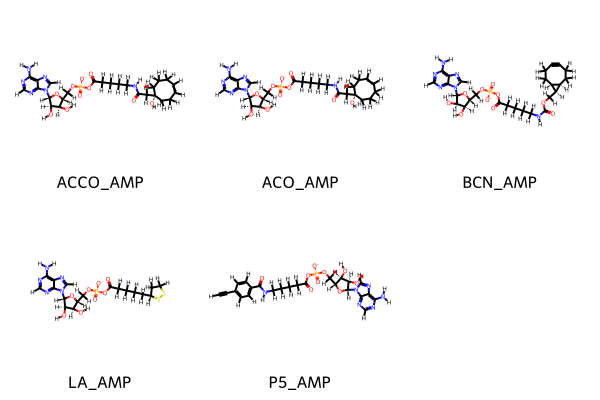

In [9]:
# Extract the contents of the sdf file and visualise it
ligands_rdmol = list(suppl)

for ligand_rdmol in ligands_rdmol:
    AllChem.Compute2DCoords(ligand_rdmol)

ligand_labels = [mol.GetProp("_Name") if mol.HasProp("_Name") else "" for mol in ligands_rdmol]

Draw.MolsToGridImage(ligands_rdmol, legends=ligand_labels)

## Charging the ligands

It is recommended to use a single set of charges for each ligand to ensure reproducibility between repeats or consistent charges between different legs of a calculation involving the same ligand, like a relative binding affinity calculation for example. 

Here we will use some utility functions from OpenFE which can assign partial charges to a series of molecules with a variety of methods which can be configured via the `OpenFFPartialChargeSettings` class. In this example 
we will charge the ligands using the `am1bcc` method from `ambertools` which is the default charge scheme used by OpenFE.

In [10]:
if CHARGED_LIGANDS_PATH.exists():
    with CHARGED_LIGANDS_PATH.open("rb") as f:
        charged_ligands = pickle.load(f)
else:
    charge_settings = OpenFFPartialChargeSettings(
        partial_charge_method="am1bcc", off_toolkit_backend="ambertools"
    )

    charged_ligands = bulk_assign_partial_charges(
        molecules=ligands,
        overwrite=False,
        method=charge_settings.partial_charge_method,
        toolkit_backend=charge_settings.off_toolkit_backend,
        generate_n_conformers=charge_settings.number_of_conformers,
        nagl_model=charge_settings.nagl_model,
        processors=mp.cpu_count(),
    )

    with CHARGED_LIGANDS_PATH.open("wb") as f:
        pickle.dump(charged_ligands, f)

## Creating the `LigandNetwork`

The first step is to create a `LigandNetwork`, which is a network with small molecules as nodes, and atom mappings, the description of how to alchemically mutate between the molecules, as its edges.

The pipeline for creating a `LigandNetwork` can involve three components:

* **Atom Mapper**: Proposes potential atom mappings (descriptions of the alchemical change) for pairs of ligands.
* **Scorer**: Given an atom mapping, provides an estimate of the quality of that mapping (higher scores are better).
* **Network Planner**: Creates the actual `LigandNetwork`; different network planners provide different strategies.

Each of these components could be replaced by other options.

In [ ]:
lomap_mapper = openfe.LomapAtomMapper(
    time=20,  # Time out if MCS algorithm takes 20 seconds
    threed=True,  # Use atom positions to prune symmetric mappings
    max3d=1.0,  # Forbid mapping between atoms more than 1.0 Å apart
    element_change=True,  # Allow mappings that change an atoms element
    seed="",  # Empty SMARTS string causes MCS search to start from scratch
    shift=False,  # Keep pre-aligned atom positions for 3D position checks
)
kartograf_mapper = openfe.KartografAtomMapper(atom_map_hydrogens=True)

# Passing multiple atom mappers to the planner
mappers = [lomap_mapper, kartograf_mapper]
scorer = openfe.lomap_scorers.default_lomap_score
network_planner = openfe.ligand_network_planning.generate_lomap_network

# Custom network planners
custom_network_planner_from_names = openfe.ligand_network_planning.generate_network_from_names
custom_network_planner_from_indices = openfe.ligand_network_planning.generate_network_from_indices

The exact call signature depends on the network planner: a minimal spanning network requires a score, whereas that is optional for a radial network (but a radial network needs the central ligand to be provided).

You can output the ligand network to the same `graphml` format as we saw in the CLI tutorial with the following:

Now we can look at the overall structure of the `LigandNetwork`:

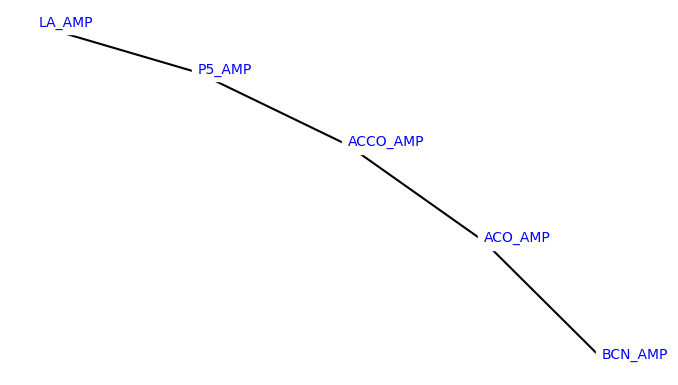

In [ ]:
ligand_network = network_planner(ligands=charged_ligands, mappers=mappers, scorer=scorer)
plot_atommapping_network(ligand_network)

with LIGAND_NETWORK_PATH.open("w", encoding="utf-8") as f:
    f.write(ligand_network.to_graphml())

We can also inspect the individual atom mappings:

To get the score for this mapping, we inspect its `annotations` attribute. Arbitrary annotations can be added when a mapping is created, although our network generator only includes the score.

{'score': 0.07427357821433388}


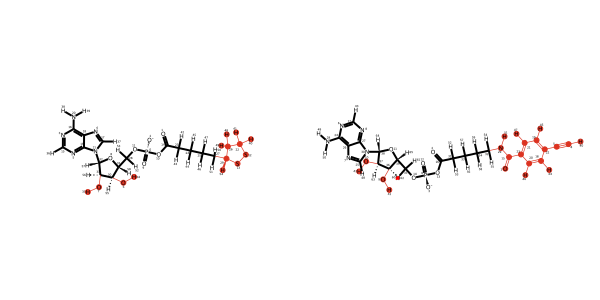

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.049787068367863924}


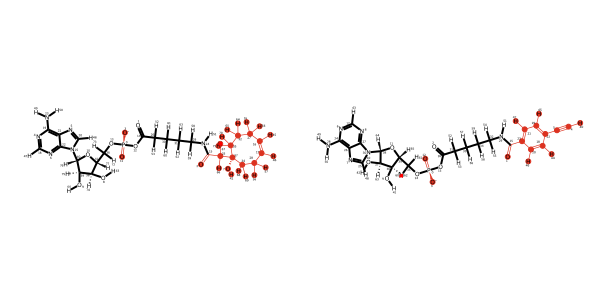

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.7408182206817179}


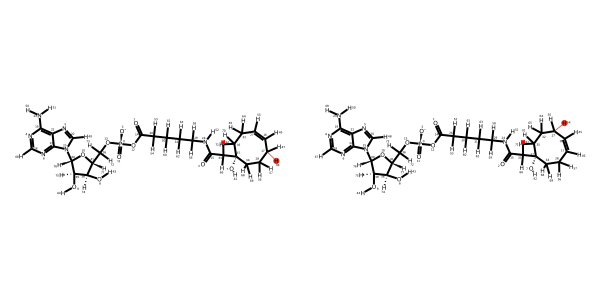

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.1224564282529819}


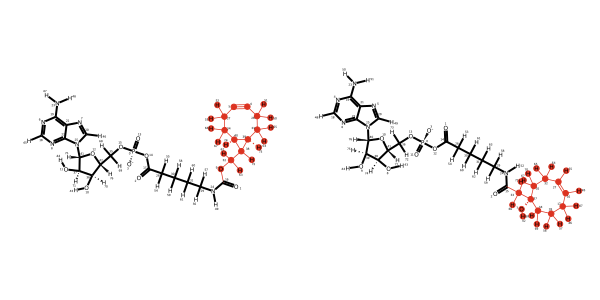

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
for mapping in ligand_network.edges:
    print(mapping.annotations)
    display(mapping)
    display(mapping.view_3d(show_atomIDs=True))

## Creating a single `Transformation`

The `LigandNetwork` only knows about the small molecules and the alchemical connections between them. It doesn't know anything about environment (e.g., solvent) or about the `Protocol` that will be used during the simulation.

That information in included in a `Transformation`. Each of these transformations corresponds to a single leg of the simulation campaign, so for each edge in the `LigandNetwork`, we will create two `Transformation`s: one for the complex and one for solvent.

In practice, this will be done for each edge of the `LigandNetwork` in a loop, but for illustrative purposes we'll dive into the details of creating a single transformation. In particular, we'll create the solvent leg for the pair of molecules we selecting for the mapping above.

### Creating `ChemicalSystem`s

OpenFE describes complex molecular systems as being composed of `Component`s. For example, we have `SmallMoleculeComponent` for each small molecule in the `LigandNetwork`. We'll create a `SolventComponent` to describe the solvent, and binding free energy calculations involve a `ProteinComponent`.

The `Component`s are joined in a `ChemicalSystem`, which describes all the particles in the simulation.

In [14]:
# defaults are water with NaCl at 0.15 M
solvent = openfe.SolventComponent()

In [15]:
protein = openfe.ProteinComponent.from_pdb_file(
    str(FIXED_PROTEIN_PATH), name=FIXED_PROTEIN_PATH.stem
)

### Creating a `Protocol`

The actual simulation is performed by a `Protocol`. We'll use an OpenMM-based hybrid topology relative free energy `Protocol`.

The easiest way to customize protocol settings is to start with the default settings, and modify them. Many settings carry units with them.

We use the default settings with an adapted solvent padding for the complex phase to avoid adding too many waters.

**Note: Since [OpenFE v1.5.0](https://docs.openfree.energy/en/v1.6.1/CHANGELOG.html#v1-5-0), `real_time_analysis_interval` does not need to be divisible by `checkpoint_interval`.**

**Note: by default the settings use a solvent padding of 1.5 nm, this is appropriate for solvent simulations, but for complex simulations this leads to excess water being in the box, slowing down your simulation. To deal with this, we will create two sets of settings, and two sets of protocols, one for each leg of the transformations.**

In [ ]:
complex_settings = RelativeHybridTopologyProtocol.default_settings()

# Change the value
complex_settings.thermo_settings.temperature = TEMPERATURE * unit.kelvin
complex_settings.thermo_settings.ph = PH
complex_settings.simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond
complex_settings.simulation_settings.n_replicas = LAMBDA_WINDOWS
complex_settings.lambda_settings.lambda_windows = LAMBDA_WINDOWS

# Reduce the solvent padding for the complex phase
complex_settings.solvation_settings.solvent_padding = 1 * unit.nanometer

complex_protocol = RelativeHybridTopologyProtocol(complex_settings)

complex_settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': False,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml'],
                         'hydrogen_mass': 3.0,
                         'nonbonded_cutof

In [ ]:
solvent_settings = RelativeHybridTopologyProtocol.default_settings()

# Change the value
solvent_settings.thermo_settings.temperature = TEMPERATURE * unit.kelvin
solvent_settings.thermo_settings.ph = PH
solvent_settings.simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond
solvent_settings.simulation_settings.n_replicas = LAMBDA_WINDOWS
solvent_settings.lambda_settings.lambda_windows = LAMBDA_WINDOWS

solvent_protocol = RelativeHybridTopologyProtocol(solvent_settings)

solvent_settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': False,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml'],
                         'hydrogen_mass': 3.0,
                         'nonbonded_cutof

### Creating the `Transformation`

Once we have the mapping, the two `ChemicalSystem`s, and the `Protocol`, creating the `Transformation` is easy:

To summarize, this `Transformation` contains:
- chemical models of both sides of the alchemical transformation in `systemA` and `systemB`
- the correspondence of items in these two sides in `mapping` 
- a description of the exact computational algorithm to use to perform the estimate in `complex_protocol`

## Creating the `AlchemicalNetwork`

The `AlchemicalNetwork` contains all the information needed to run the entire campaign. It consists of a `Transformation` for each leg of the campaign. We'll loop over all the mappings, and then loop over the legs. In that inner loop, we'll make each transformation.

We can also use the `RBFEAlchemicalNetworkPlanner` to create an `AlchemicalNetwork`.

In [18]:
transformations = []
for mapping in ligand_network.edges:
    for leg in ["solvent", "complex"]:
        # use the solvent and protein created above
        sysA_dict = {"ligand": mapping.componentA, "solvent": solvent}
        sysB_dict = {"ligand": mapping.componentB, "solvent": solvent}

        if leg == "complex":
            # If this is a complex transformation we use the complex protocol
            # and add in the protein to the chemical states
            protocol = complex_protocol
            sysA_dict["protein"] = protein
            sysB_dict["protein"] = protein
        else:
            # If this is a solvent transformation we just use the solvent protocol
            protocol = solvent_protocol

        # we don't have to name objects, but it can make things (like filenames) more convenient
        sysA = openfe.ChemicalSystem(sysA_dict, name=f"{mapping.componentA.name}_{leg}")
        sysB = openfe.ChemicalSystem(sysB_dict, name=f"{mapping.componentB.name}_{leg}")

        prefix = "rbfe_"  # prefix is only to exactly reproduce CLI

        transformation = openfe.Transformation(
            stateA=sysA,
            stateB=sysB,
            mapping=mapping,
            protocol=protocol,  # use protocol created above
            name=f"{prefix}{sysA.name}_{sysB.name}",
        )
        transformations.append(transformation)

network = openfe.AlchemicalNetwork(transformations)

In [19]:
def mock_transformation(transformation: openfe.Transformation) -> None:
    """Dry-run the setup stage of a transformation to validate inputs."""
    dag = transformation.create()

    # Find the setup unit
    setup_units = [unit for unit in dag.protocol_units if "Setup" in type(unit).__name__]
    if not setup_units:
        # Fallback: run the first unit (many protocols start with setup)
        setup_units = [next(iter(dag.protocol_units))]

    with tempfile.TemporaryDirectory() as temp_dir:
        base = Path(temp_dir)
        for unit in setup_units:
            unit.run(
                dry=True,
                verbose=True,
                scratch_basepath=base / "scratch",
                shared_basepath=base / "shared",
            )


# Mocking the transformations
# with mp.Pool(processes=mp.cpu_count()) as pool:
#     pool.map(mock_transformation, transformations)

## Writing the `AlchemicalNetwork` to disk

We'll write out each transformation to disk, so that they can be run independently using the `openfe quickrun` command:

In [20]:
# We write out each transformation
for transformation in network.edges:
    transformation.to_json(TRANSFORMATION_DIR / f"{transformation.name}.json")

# List contents of the transformations directory
os.listdir(TRANSFORMATION_DIR)

['rbfe_BCN_AMP_complex_ACO_AMP_complex.json',
 'rbfe_BCN_AMP_solvent_ACO_AMP_solvent.json',
 'rbfe_LA_AMP_complex_P5_AMP_complex.json',
 'rbfe_ACCO_AMP_complex_P5_AMP_complex.json',
 'rbfe_ACCO_AMP_solvent_P5_AMP_solvent.json',
 'rbfe_ACO_AMP_complex_ACCO_AMP_complex.json',
 'rbfe_LA_AMP_solvent_P5_AMP_solvent.json',
 'rbfe_ACO_AMP_solvent_ACCO_AMP_solvent.json']

Each of these individual `.json` files contains a `Transformation`, which contains all the information to run the calculation.  These could be farmed out as individual jobs on a HPC cluster. These files are identical to what were created in setup stage of the CLI tutorial; for details on running them, follow from the section on running simulations in the CLI tutorial